count    102.000000
mean     553.700873
std       21.556812
min      500.014000
25%      539.563750
50%      556.641000
75%      567.973750
max      604.532000
Name: deploymentTime, dtype: float64
count    101.000000
mean     543.791040
std       20.916648
min      494.436000
25%      530.644000
50%      540.510000
75%      558.818000
max      594.912000
Name: deploymentTime, dtype: float64
count    102.000000
mean     539.037275
std       21.722416
min      498.409000
25%      525.561750
50%      536.026000
75%      551.477500
max      591.722000
Name: deploymentTime, dtype: float64
count    102.000000
mean     532.237882
std       21.918351
min      485.777000
25%      518.059250
50%      532.902500
75%      544.660750
max      596.311000
Name: deploymentTime, dtype: float64
584.563


<Axes: >

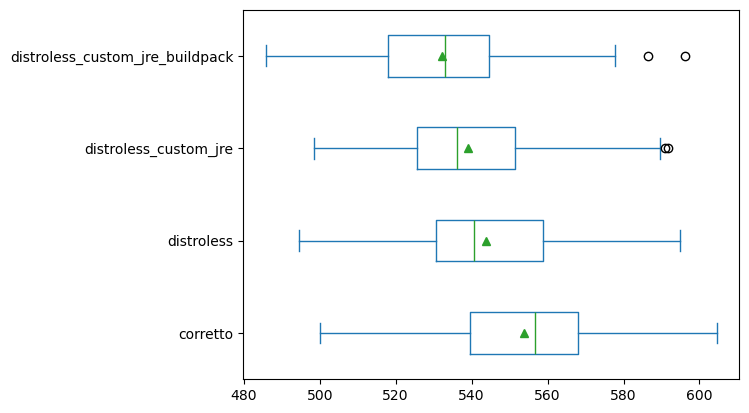

In [12]:
import pandas as pd

corretto = pd.read_json("./data/corretto.json")
corretto["deploymentTime"] = (pd.to_datetime(corretto["finishedAt"])- pd.to_datetime(corretto["startedAt"])).dt.total_seconds()
corretto.loc[corretto["status"] != "SUCCESSFUL", "deploymentTime"] = float("nan")

distroless = pd.read_json("./data/distroless.json")
distroless["deploymentTime"] = (pd.to_datetime(distroless["finishedAt"])- pd.to_datetime(distroless["startedAt"])).dt.total_seconds()
distroless.loc[distroless["status"] != "SUCCESSFUL", "deploymentTime"] = float("nan")

distroless_custom_jre = pd.read_json("./data/distroless-custom-jre.json")
distroless_custom_jre["deploymentTime"] = (pd.to_datetime(distroless_custom_jre["finishedAt"])- pd.to_datetime(distroless_custom_jre["startedAt"])).dt.total_seconds()
distroless_custom_jre.loc[distroless_custom_jre["status"] != "SUCCESSFUL", "deploymentTime"] = float("nan")

distroless_custom_jre_buildpack = pd.read_json("./data/distroless-custom-jre-buildpack.json")
distroless_custom_jre_buildpack["deploymentTime"] = (pd.to_datetime(distroless_custom_jre_buildpack["finishedAt"])- pd.to_datetime(distroless_custom_jre_buildpack["startedAt"])).dt.total_seconds()
distroless_custom_jre_buildpack.loc[distroless_custom_jre_buildpack["status"] != "SUCCESSFUL", "deploymentTime"] = float("nan")

print(corretto["deploymentTime"].describe())
print(distroless["deploymentTime"].describe())
print(distroless_custom_jre["deploymentTime"].describe())
print(distroless_custom_jre_buildpack["deploymentTime"].describe())

# 四分位数
q1 = distroless_custom_jre_buildpack["deploymentTime"].describe()['25%']
q3 = distroless_custom_jre_buildpack["deploymentTime"].describe()['75%']
iqr = q3 - q1 #四分位範囲

# 外れ値の基準点
outlier_min = q1 - (iqr) * 1.5
outlier_max = q3 + (iqr) * 1.5
print(outlier_max)

deployment_time = pd.DataFrame()
deployment_time["corretto"] = corretto["deploymentTime"]
deployment_time["distroless"] = distroless["deploymentTime"]
deployment_time["distroless_custom_jre"] = distroless_custom_jre["deploymentTime"]
deployment_time["distroless_custom_jre_buildpack"] = distroless_custom_jre_buildpack["deploymentTime"]
deployment_time.plot.box(showmeans=True, vert=False)